<h1><b><center>Terrain Quantities using GeoidLab</center></b></h1>
<p style="text-align: center; font-size: 1.2em; color: white;">
    Author: Caleb Kelly<br>
</p>

This notebook demonstrates the main terrain-modeling workflows exposed by `geoidlab.terrain`. The goal is to show how to

1. instantiate a `TerrainQuantities`,
2. compute terrain corrections ($C$),
3. compute the primary indirect topographic effect (PITE),
4. RTM gravity and height anomalies, and
5. use a DTM in MATLAB's `.mat` format.

The examples are intentionally lightweight so that the notebook is easy to read and adapt. If this is your first time using the terrain tools in `geoidlab`, execute the cells from top to bottom.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from geoidlab.terrain import TerrainQuantities as TQ
from geoidlab.dem import dem4geoid
from pathlib import Path

PROJECT_DIR = Path('GeoidProject')
DOWNLOAD_DIR = PROJECT_DIR / 'downloads'
RESULTS_DIR = PROJECT_DIR / 'results'

In [3]:
from geoidlab.mapping.colormaps import bright_rainbow_cmap, cpt_cmap
from matplotlib.colors import Colormap, ListedColormap

CUSTOM_CMAPS: dict[str, ListedColormap] = {
    'bright_rainbow': bright_rainbow_cmap()
}

def get_colormap(cmap_name: str) -> Colormap:
    '''Retrieve colormap by name, handling custom and GMT .cpt colormaps'''
    if cmap_name in CUSTOM_CMAPS:
        return CUSTOM_CMAPS[cmap_name]
    elif cmap_name.endswith('.cpt'):
        return cpt_cmap(cmap_name)
    else:
        try:
            return plt.get_cmap(cmap_name)
        except ValueError:
            raise ValueError(f'Invalid colormap: {cmap_name}. Use --list-cmaps to see available options.')

# Digital Elevation Model

In [ ]:
bbox_off = 2
resolution = 0.02

bbox = [-4, 2, 4, 12]
dem = dem4geoid(
    bbox=bbox,
    downloads_dir=DOWNLOAD_DIR,
    resolution=resolution * 3600,
    bbox_off=bbox_off,
    model='cop'
)
dem

cop_dem.nc exists and covers bbox. Using local copy.

Creating xarray dataset of DEM with buffer of 2 degree(s)

Aligning DEM to bounding box and resampling DEM to 72.0 arc-seconds...
DEM alignment and resampling completed in 3.29 seconds.



<xarray.Dataset> Size: 2MB
Dimensions:      (y: 601, x: 501)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * x            (x) float64 4kB -6.0 -5.98 -5.96 -5.94 ... 3.94 3.96 3.98 4.0
  * y            (y) float64 5kB 2.0 2.02 2.04 2.06 ... 13.94 13.96 13.98 14.0
Data variables:
    z            (y, x) float64 2MB nan nan nan nan ... 237.9 247.0 249.0 nan
Attributes:
    date_created:  2026-03-31 15:48:55 Asia/Shanghai
    created_by:    GeoidLab
    website:       https://github.com/cikelly/geoidlab
    copyright:     Copyright (c) 2026, Caleb Kelly

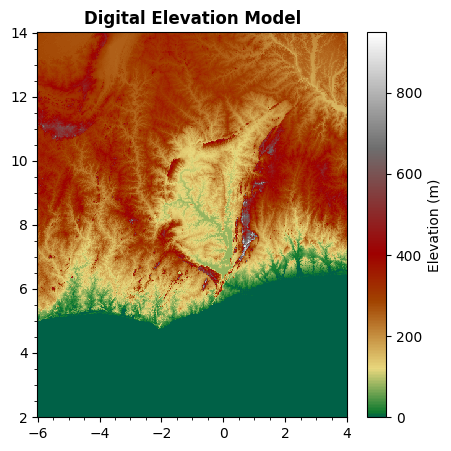

In [5]:
dem['z'].plot(cmap=get_colormap('DEM_poster.cpt'), figsize=(5, 5), cbar_kwargs={'label': 'Elevation (m)'}, vmin=0)
plt.title('Digital Elevation Model', fontweight='bold')
plt.minorticks_on()
plt.grid(which='minor', linewidth=0.001)
plt.xlabel('')
plt.ylabel('')
plt.show()

# Terrain Correction

radius = 167 km, the standard value used to approximate the outer limit of the classical **Hayford-Bowie zone O**.

Initialize `TerrainQuantities` class. In addition to the constant density of $\rho=2.67$ g/cm3, `geoidlab` also uses a topographic density model from UNB. Variable density can produce more precise results particular in complex topographies. Use `constant_density=False` to use the UNB model.

In [6]:
ellipsoid = 'wgs84'

tq = TQ(
    ori_topo=dem,
    radius=167,
    ellipsoid=ellipsoid,
    bbox_off=bbox_off,
    proj_dir=PROJECT_DIR,
    constant_density=True
)

In [7]:
# tq.window_mode = 'fixed'
tc = tq.terrain_correction(parallel=True)

Computing terrain correction...
###############
Completed.
Saving terrain correction to GeoidProject/TC.nc...
Terrain correction computation completed.


Now, we use UNB topo density and compare the two

In [8]:
tq = TQ(
    ori_topo=dem,
    radius=167,
    ellipsoid=ellipsoid,
    bbox_off=bbox_off,
    proj_dir=PROJECT_DIR,
    constant_density=False,
    density_download_dir=DOWNLOAD_DIR
)
tc_variable = tq.terrain_correction(parallel=True)

Computing terrain correction...
##############
Completed.
Saving terrain correction to GeoidProject/TC.nc...
Terrain correction computation completed.


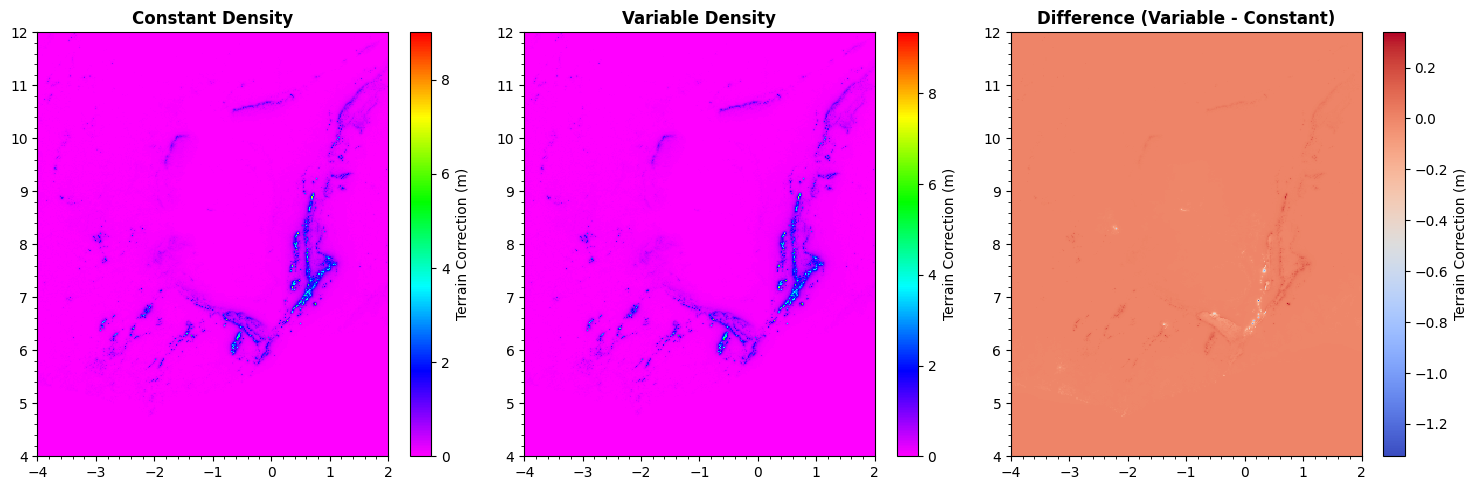

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()

im = axs[0].pcolormesh(
    tq.LonP, tq.LatP, tc, cmap=get_colormap('GMT_rainbow.cpt'), shading='auto'
)
fig.colorbar(im, ax=axs[0], label='Terrain Correction (m)')

im = axs[1].pcolormesh(
    tq.LonP, tq.LatP, tc_variable, cmap=get_colormap('GMT_rainbow.cpt'), shading='auto'
)
fig.colorbar(im, ax=axs[1], label='Terrain Correction (m)')

im = axs[2].pcolormesh(
    tq.LonP, tq.LatP, tc_variable - tc, cmap=get_colormap('coolwarm'), shading='auto'
)
fig.colorbar(im, ax=axs[2], label='Terrain Correction (m)')

titles = ['Constant Density', 'Variable Density', 'Difference (Variable - Constant)']
for ax, title in zip(axs, titles):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    ax.set_xlim([-4, 2])
    ax.set_ylim([4, 12])
    
    ax.minorticks_on()
    ax.grid(which='minor', linewidth=0.001)

plt.tight_layout()
plt.show()
# for ax in axs:

In [15]:
diff = tc_variable - tc
print(f'Max difference : {diff.max():.2f} mGal')
print(f'Min difference : {diff.min():.2f} mGal')
print(f'Mean difference: {diff.mean():.2f} mGal')
print(f'Std difference : {diff.std():.2f} mGal') 

Max difference : 0.34 mGal
Min difference : -1.33 mGal
Mean difference: 0.00 mGal
Std difference : 0.01 mGal


# Primary Indirect Topographic Effect

In [16]:
pite = tq.indirect_effect(parallel=True)

Computing potential change of irregular part...
##################
Completed.
Saving the indirect effect to GeoidProject/N_ind.nc...
Indirect effect computation completed.


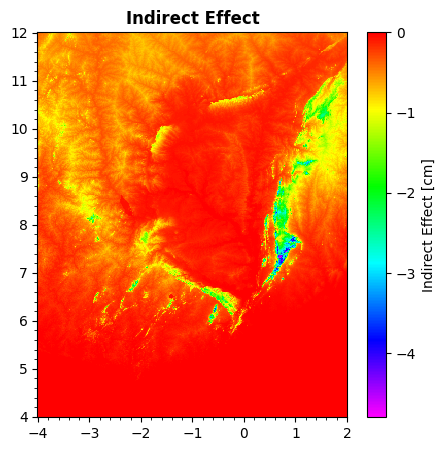

In [17]:

vmax = None
extend = None # 'max', 'both', 'min'
fig, ax = plt.subplots(1,1, figsize=(5, 5))
im = ax.pcolormesh(tq.LonP, tq.LatP, pite * 100, cmap=get_colormap('GMT_rainbow.cpt'))
fig.colorbar(im, ax=ax, label='Indirect Effect [cm]', extend=extend)
# ax.plot(gh_df.lon, gh_df.lat, 'k', linewidth=1.5)
ax.grid(which='major', linewidth=0., color='k')
ax.minorticks_on()
ax.grid(which='minor', linewidth=0., color='k')

ax.set_title('Indirect Effect', fontweight='bold')
# plt.savefig('indirect_effect.png', dpi=300)
plt.show()

# Secondary Indirect Topographic Effect

In [19]:
site = tq.secondary_indirect_effect()

Computing the secondary indirect effect on gravity...
Secondary indirect effect on gravity computation completed.


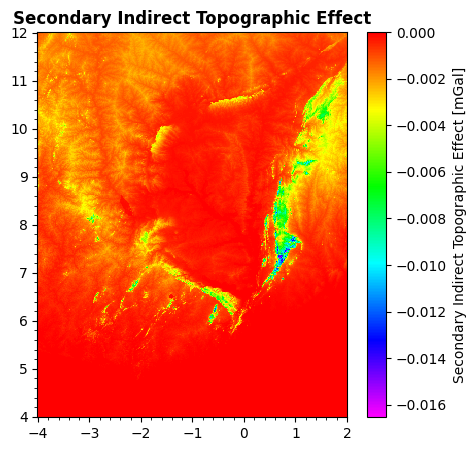

In [20]:

vmax = None
extend = None # 'max', 'both', 'min'
fig, ax = plt.subplots(1,1, figsize=(5, 5))
im = ax.pcolormesh(tq.LonP, tq.LatP, site, cmap=get_colormap('GMT_rainbow.cpt'))
fig.colorbar(im, ax=ax, label='Secondary Indirect Topographic Effect [mGal]', extend=extend)
# ax.plot(gh_df.lon, gh_df.lat, 'k', linewidth=1.5)
ax.grid(which='major', linewidth=0., color='k')
ax.minorticks_on()
ax.grid(which='minor', linewidth=0., color='k')

ax.set_title('Secondary Indirect Topographic Effect', fontweight='bold')
# plt.savefig('secondary Indirect Topographic_effect.png', dpi=300)
plt.show()

# Residual Terrain Modeling

For RTM, we need to specify a residual terrain model. `geoidlab` supports DTM2006.0 and EARTH2014. `DTM.ipynb` already demonstrates how to create a reference topography using `dtm.py`. Please consult the notebook to create a NetCDF file of synthesized topography for your study area.

In this notebook, we are simply going to smooth `dem` and use that as our `ref_topo`.

Make sure you set `radius_deg` in the next code cell to the same value as the value for `resolution` that you used in `dem4geoid` to create `dem`.

In [ ]:
import xarray as xr
from scipy.ndimage import gaussian_filter

def apply_gaussian_filter(x, sigma) -> xr.DataArray:
    return gaussian_filter(x, sigma=sigma)

grid_spacing = dem.x[1].values - dem.x[0].values
radius_deg = resolution
sigma = radius_deg / grid_spacing
ref_dem =  apply_gaussian_filter(dem.z, sigma=sigma)

ref_dem = xr.Dataset(
    {
        'z': (['y', 'x'], ref_dem)
    },
    coords={
        'x': dem['x'].values,
        'y': dem['y'].values
    }
)
ref_dem

<xarray.Dataset> Size: 2MB
Dimensions:  (y: 601, x: 501)
Coordinates:
  * x        (x) float64 4kB -6.0 -5.98 -5.96 -5.94 -5.92 ... 3.94 3.96 3.98 4.0
  * y        (y) float64 5kB 2.0 2.02 2.04 2.06 2.08 ... 13.94 13.96 13.98 14.0
Data variables:
    z        (y, x) float64 2MB nan nan nan nan nan nan ... nan nan nan nan nan

In [36]:
# tq.ref_topo = ref_dem
tq = TQ(
    ori_topo=dem,
    radius=167,
    ellipsoid=ellipsoid,
    bbox_off=bbox_off,
    proj_dir=PROJECT_DIR,
    constant_density=False,
    density_download_dir=DOWNLOAD_DIR,
    ref_topo=ref_dem
)

Resampling reference topography to match original topography grid...



## RTM Anomalies

For RTM gravity anomalies, depending on the complexity of the topography, `geoidlab` implements the approximate and exact, controlled by `approximation=True`. If the topography of your study area is not complex, and especially if you already have terrain correction computed in your area, you might find that the approximate solution could be a reasonable solution and a timesaver.

In [38]:
dg_rtm_approx = tq.rtm_anomaly(approximation=True, tc=tc_variable)

Computing RTM gravity anomalies...
Saving RTM gravity anomalies to GeoidProject/RTM.nc...
RTM gravity anomalies computation completed.


In [39]:
dg_rtm_exact = tq.rtm_anomaly(approximation=False, tc=tc_variable)

Computing RTM terrain correction...
Saving RTM gravity anomalies to GeoidProject/RTM.nc...
RTM gravity anomalies computation completed.


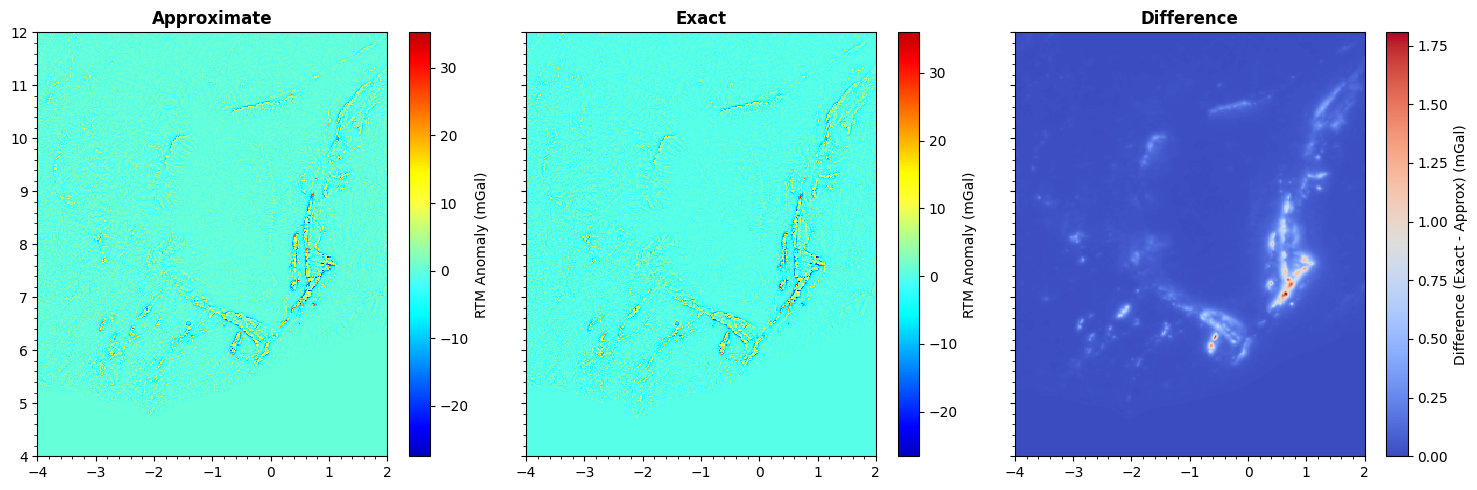

In [42]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
axs = axs.flatten()

im = axs[0].pcolormesh(tq.LonP, tq.LatP, dg_rtm_approx, cmap=get_colormap('jet.cpt'), shading='auto')
fig.colorbar(im, ax=axs[0], label='RTM Anomaly (mGal)')

im = axs[1].pcolormesh(tq.LonP, tq.LatP, dg_rtm_exact, cmap=get_colormap('jet.cpt'), shading='auto')
fig.colorbar(im, ax=axs[1], label='RTM Anomaly (mGal)')

im = axs[2].pcolormesh(tq.LonP, tq.LatP, dg_rtm_exact - dg_rtm_approx, cmap=get_colormap('coolwarm'), shading='auto')
fig.colorbar(im, ax=axs[2], label='Difference (Exact - Approx) (mGal)')

titles = ['Approximate', 'Exact', 'Difference']

for ax, title in zip(axs, titles):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    ax.set_xlim([-4, 2])
    ax.set_ylim([4, 12])
    
    ax.minorticks_on()
    ax.grid(which='minor', linewidth=0.001) 
    
plt.tight_layout()
plt.show()

Note that our RTM gravity anomalies are largely zero because our original and reference topographies are quite similar (take another look at the plot of the reference topography). Our smoothing was rather weak.

We will later demonstrate how you might use `ref_topo` and `ori_topo` that are in different formats using the `DTMZ.mat` file in `GeoidProject/downloads` directory of the repo.

`geoidlab` already comes packed with a utility for reading/loading `.mat` files. However, this shouldn't preclude the use of custom datasets in other formats.

## RTM Height Anomalies

In [43]:
zeta = tq.rtm_height_anomaly(parallel=True)

Computing RTM height anomaly...
##################
Completed.
Saving RTM height anomaly to GeoidProject/zeta_rtm.nc...
RTM height anomaly computation completed.


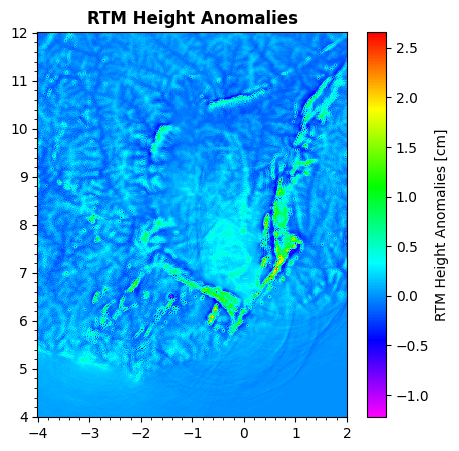

In [44]:
vmax = None
extend = None # 'max', 'both', 'min'
fig, ax = plt.subplots(1,1, figsize=(5, 5))
im = ax.pcolormesh(tq.LonP, tq.LatP, zeta*100, cmap=get_colormap('GMT_rainbow.cpt'), shading='auto', vmax=vmax)
fig.colorbar(im, ax=ax, label='RTM Height Anomalies [cm]', extend=extend)

ax.grid(which='major', linewidth=0., color='k')
ax.minorticks_on()
ax.grid(which='minor', linewidth=0., color='k')
ax.set_title('RTM Height Anomalies', fontweight='bold')

plt.show()

# CUSTOM DEM and DTM

Example using `DTMZ.mat`

In [45]:
from geoidlab.utils import matlab_io

fname = DOWNLOAD_DIR / 'DTMZ.mat'
mat = matlab_io.MATLABIO(fname)

dem = mat.read_mat(to_xarray=True)
dem

<xarray.Dataset> Size: 18MB
Dimensions:  (lat: 1201, lon: 961)
Coordinates:
  * lat      (lat) float64 10kB 3.0 3.008 3.017 3.025 ... 12.97 12.98 12.99 13.0
  * lon      (lon) float64 8kB -5.0 -4.992 -4.983 -4.975 ... 2.983 2.992 3.0
Data variables:
    grid1    (lat, lon) float64 9MB -4.383e+03 -4.392e+03 ... 225.0 223.5
    grid2    (lat, lon) float64 9MB -4.437e+03 -4.437e+03 ... 239.8 239.7

In [50]:
print(f'Grid spacing: {abs(dem.lat[0].values - dem.lat[1].values)}')

Grid spacing: 0.008333333333333304


Note that because of the much smaller grid spacing, processing with this custom data will take longer than the previous examples.

In [46]:
ori_topo = dem['grid1']
ori_topo = ori_topo.to_dataset(name='z')
ref_topo = dem['grid2']
ref_topo = ref_topo.to_dataset(name='z')

In [47]:
bbox_off = 1
tq = TQ(
    ori_topo=ori_topo, ellipsoid=ellipsoid, 
    radius=110, bbox_off=bbox_off,
    ref_topo=ref_topo,
    window_mode='radius',
)

## Gravity Anomalies

In [53]:
dg_rtm = tq.rtm_anomaly(parallel=True, progress=True, chunk_size=20)

Computing RTM terrain correction...
###########################################################################################################################################################################################################################################
Completed.
Saving RTM gravity anomalies to current directory (RTM.nc)...
RTM gravity anomalies computation completed.


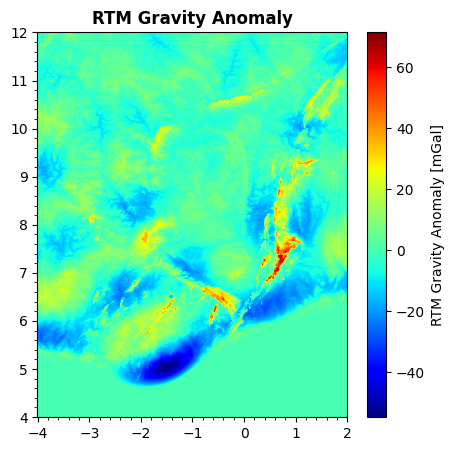

In [54]:
vmax = None
extend = None # 'max', 'both', 'min'
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im = ax.pcolormesh(tq.LonP, tq.LatP, dg_rtm, cmap='jet', vmax=vmax)
fig.colorbar(im, ax=ax, label='RTM Gravity Anomaly [mGal]', extend=extend)

ax.minorticks_on()
ax.grid(which='minor', linewidth=0., color='k')
ax.set_title('RTM Gravity Anomaly', fontweight='bold')

plt.show()

## Height Anomalies

In [55]:
zeta = tq.rtm_height_anomaly(parallel=True, chunk_size=20)

Computing RTM height anomaly...
#################################################################################################################################################################################################
Completed.
Saving RTM height anomaly to current directory (zeta_rtm.nc)...
RTM height anomaly computation completed.


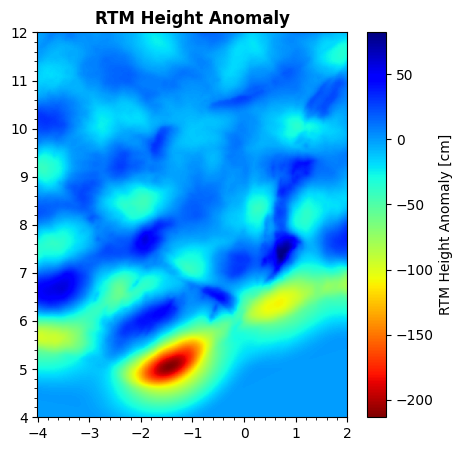

In [58]:
vmax = None
extend = None # 'max', 'both', 'min'
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im = ax.pcolormesh(tq.LonP, tq.LatP, zeta*100, cmap='jet_r', vmax=vmax)
fig.colorbar(im, ax=ax, label='RTM Height Anomaly [cm]', extend=extend)

ax.minorticks_on()
ax.grid(which='minor', linewidth=0., color='k')
ax.set_title('RTM Height Anomaly', fontweight='bold')

plt.show()